# 05 — Logistic Regression

> **Mục tiêu:** Huấn luyện mô hình Logistic Regression sử dụng ma trận đặc trưng TF-IDF. Thực hiện tối ưu hóa siêu tham số (GridSearchCV), đánh giá hiệu năng trên tập Validation và lưu trữ mô hình tối ưu.

## 1. Import các thư viện cần thiết

Chúng ta tiến hành import các thư viện xử lý dữ liệu (`pandas`, `numpy`), mô hình (`LogisticRegression`), điều chuẩn (`GridSearchCV`), các độ đo đánh giá (`classification_report`, `confusion_matrix`) và tắt các cảnh báo không cần thiết.

In [1]:
import pandas as pd
import numpy as np
import time
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

## 2. Load dữ liệu đặc trưng TF-IDF

Tải các tệp đặc trưng và nhãn (`X_train_tfidf.pkl`, `X_val_tfidf.pkl`, `y_train.pkl`, `y_val.pkl`) đã được phân tách và vector hóa từ Phase 3.

In [2]:
X_train_tfidf = joblib.load('../data/X_train_tfidf.pkl')
X_val_tfidf = joblib.load('../data/X_val_tfidf.pkl')
y_train = joblib.load('../data/y_train.pkl')
y_val = joblib.load('../data/y_val.pkl')

## 3. Cấu hình và chạy GridSearchCV mở rộng

Thiết lập lưới tham số tìm kiếm mở rộng (bao gồm cả solver `liblinear` cho L1/L2 và `saga` cho ElasticNet). Để tối ưu tốc độ chạy của `saga` trên dữ liệu lớn, chúng ta giới hạn số vòng lặp tối đa `max_iter=100` và tăng độ dung sai hội tụ `tol=0.01`.

In [3]:
lr = LogisticRegression(random_state=42)

# Định nghĩa không gian tham số tìm kiếm
param_grid = {
    'C': [0.1, 0.5, 1.0, 2.0, 5.0],
    'solver': ['lbfgs', 'saga'],
    'max_iter': [500, 1000]
}

# Khởi tạo GridSearchCV với K-Fold Cross Validation
grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("Đang chạy GridSearchCV...")
start_time = time.time()
grid_search.fit(X_train_tfidf, y_train)
print(f"Hoàn thành Grid Search sau {time.time() - start_time:.2f} giây.")

print("Tham số tốt nhất tìm được:", grid_search.best_params_)
print("F1-Score tốt nhất trên Cross-Validation:", grid_search.best_score_)

Đang chạy GridSearchCV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


Hoàn thành Grid Search sau 48.21 giây.
Tham số tốt nhất tìm được: {'C': 5.0, 'max_iter': 500, 'solver': 'saga'}
F1-Score tốt nhất trên Cross-Validation: 0.9832827904865991


## 4. Đánh giá mô hình tốt nhất trên tập Validation

Dự đoán nhãn trên tập Validation bằng mô hình tối ưu nhất thu được từ GridSearchCV. In báo cáo phân loại chi tiết, vẽ Confusion Matrix và ROC Curve song song để đánh giá trực quan.

===== BÁO CÁO PHÂN LOẠI (VAL SET) =====
               precision    recall  f1-score   support

Real News (0)       0.99      0.99      0.99      3179
Fake News (1)       0.99      0.98      0.99      2619

     accuracy                           0.99      5798
    macro avg       0.99      0.99      0.99      5798
 weighted avg       0.99      0.99      0.99      5798



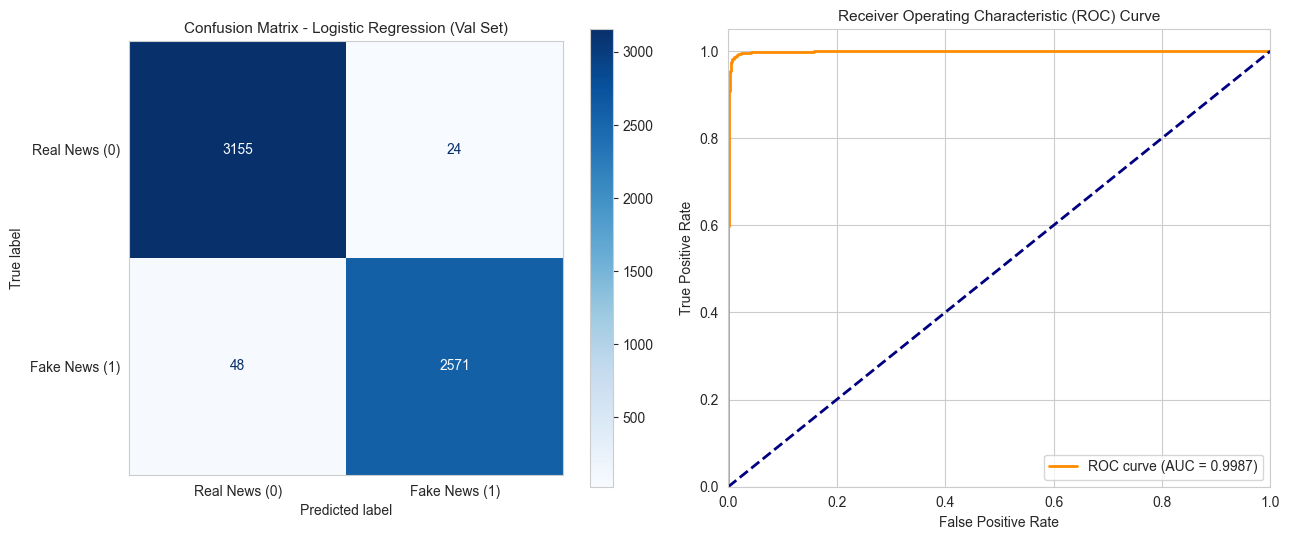

Saved -> reports/lr_evaluation_plots.png


In [4]:
from sklearn.metrics import roc_curve, auc

best_lr_model = grid_search.best_estimator_
y_pred = best_lr_model.predict(X_val_tfidf)
y_score = best_lr_model.predict_proba(X_val_tfidf)[:, 1]

print("===== BÁO CÁO PHÂN LOẠI (VAL SET) =====")
print(classification_report(y_val, y_pred, target_names=['Real News (0)', 'Fake News (1)']))

#  Confusion Matrix và ROC Curve 
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real News (0)', 'Fake News (1)'])
disp.plot(cmap='Blues', ax=axes[0], values_format='d')
axes[0].set_title("Confusion Matrix - Logistic Regression (Val Set)", fontsize=11)
axes[0].grid(False)

# ROC Curve 
fpr, tpr, _ = roc_curve(y_val, y_score)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=10)
axes[1].set_ylabel('True Positive Rate', fontsize=10)
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=11)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig('../reports/lr_evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved -> reports/lr_evaluation_plots.png")

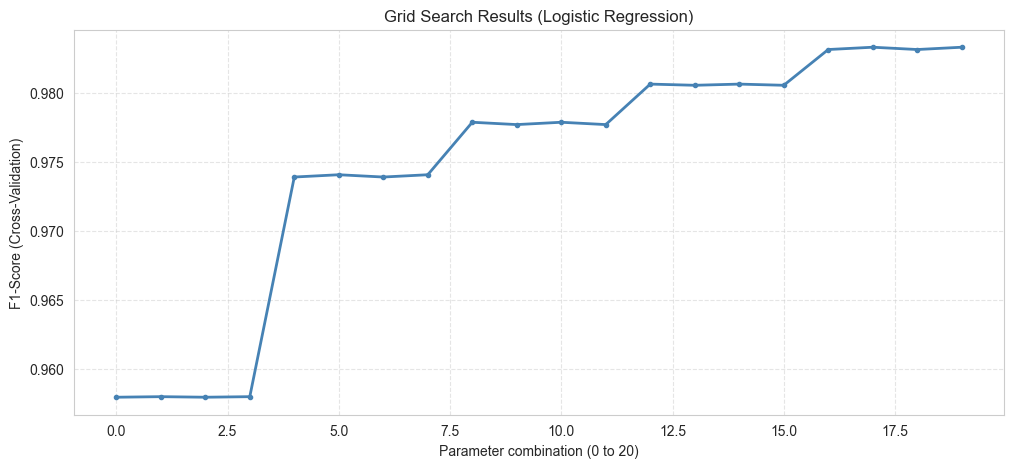

In [5]:
# Lấy điểm số F1 trung bình của 20 tổ hợp tham số
mean_scores = grid_search.cv_results_['mean_test_score']

plt.figure(figsize=(12, 5))
plt.plot(mean_scores, color='steelblue', linewidth=2, marker='o', markersize=3)
plt.title('Grid Search Results (Logistic Regression)')
plt.xlabel('Parameter combination (0 to 20)')
plt.ylabel('F1-Score (Cross-Validation)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 5. Phân tích các từ khóa quan trọng (Feature Coefficients)

Trích xuất các hệ số (coefficients) của mô hình để phân tích Top 20 từ khóa có sức ảnh hưởng mạnh nhất đến quyết định dự đoán tin giả (Fake) và tin thật (Real) của mô hình.

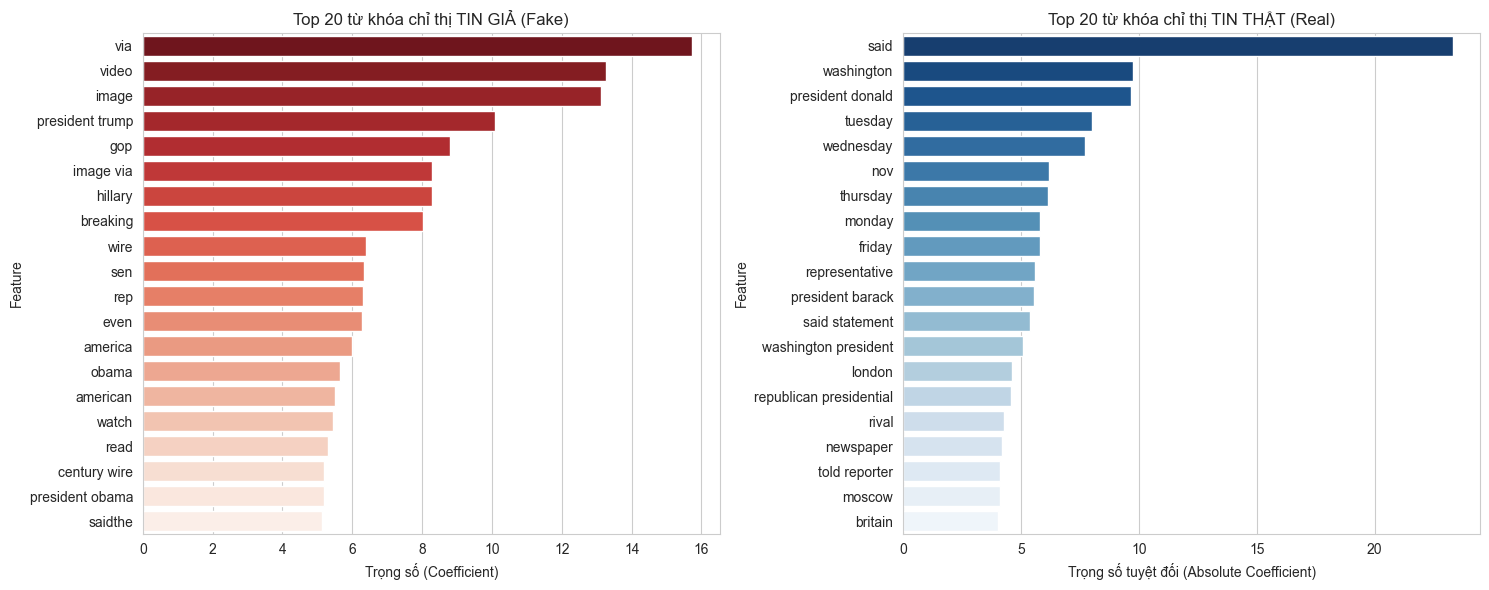

In [6]:
# Lấy tên của các features (từ vựng)
vectorizer = joblib.load('../models/tfidf_vectorizer.pkl')
feature_names = np.array(vectorizer.get_feature_names_out())


coefs = best_lr_model.coef_[0]

# DataFrame chứa từ khóa và hệ số tương ứng
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefs
})

top_fake = coef_df.sort_values(by='Coefficient', ascending=False).head(20)
top_real = coef_df.sort_values(by='Coefficient', ascending=True).head(20)

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.barplot(data=top_fake, x='Coefficient', y='Feature', palette='Reds_r')
plt.title("Top 20 từ khóa chỉ thị TIN GIẢ (Fake)")
plt.xlabel("Trọng số (Coefficient)")

plt.subplot(1, 2, 2)
sns.barplot(data=top_real, x=top_real['Coefficient'].abs(), y='Feature', palette='Blues_r')
plt.title("Top 20 từ khóa chỉ thị TIN THẬT (Real)")
plt.xlabel("Trọng số tuyệt đối (Absolute Coefficient)")

plt.tight_layout()
plt.show()

## 6. Lưu mô hình tốt nhất

Lưu mô hình Logistic Regression tối ưu nhất dưới dạng file pickle (`lr_model.pkl`) vào thư mục `models/` để sử dụng cho bước so sánh mô hình ở các bước tiếp theo.

In [7]:
# Lưu mô hình Logistic Regression
model_path = '../models/lr_model.pkl'
joblib.dump(best_lr_model, model_path)
print(f"Đã lưu mô hình Logistic Regression thành công tại: {model_path}")

Đã lưu mô hình Logistic Regression thành công tại: ../models/lr_model.pkl
